Input Angles -> Theta: 1.0472 rad (60.0°), Phi: 0.7854 rad (45.0°)

--- Statevector Comparison ---
Qiskit Statevector : [0.8001 -0.33141j 0.46194+0.19134j]
Manual Statevector : [0.86603+0.j      0.35355+0.35355j]

Absolute Numerical Difference: 3.37906350e-01

--- Validation Result ---
STATUS: VALIDATION FAILED - Discrepancy detected.

--- Quantum Circuit ---


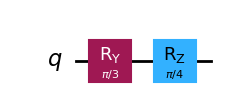


--- Bloch Sphere Representation ---


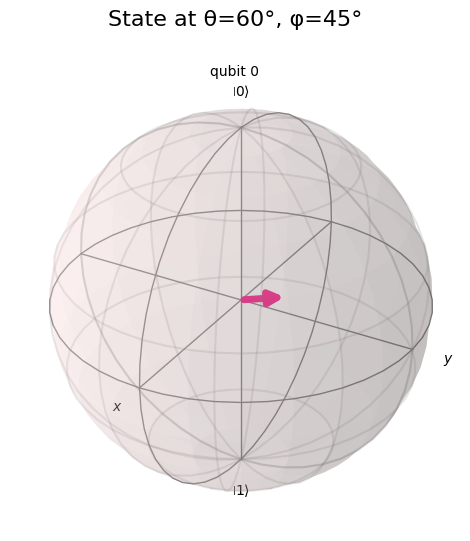

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

# 1. Define arbitrary rotation angles (in radians)
# Example: theta = pi/3 (60 degrees), phi = pi/4 (45 degrees)
theta = np.pi / 3  
phi = np.pi / 4    

print(f"Input Angles -> Theta: {theta:.4f} rad ({np.degrees(theta):.1f}°), Phi: {phi:.4f} rad ({np.degrees(phi):.1f}°)")

# 2. Construct the Quantum Circuit
qc = QuantumCircuit(1)

# Method: RY(theta) rotates from |0> towards |1> by theta, RZ(phi) applies azimuthal phase shift phi
qc.ry(theta, 0)
qc.rz(phi, 0)

# Extract Statevector from Qiskit
qiskit_state = Statevector.from_instruction(qc)

# 3. Manual Analytical Calculation
# Formula: |psi> = cos(theta/2)|0> + e^(i*phi) * sin(theta/2)|1>
amp_0 = np.cos(theta / 2)
amp_1 = np.exp(1j * phi) * np.sin(theta / 2)
manual_state_data = np.array([amp_0, amp_1])

# 4. Display & Validate Calculations
print("\n--- Statevector Comparison ---")
print("Qiskit Statevector :", np.round(qiskit_state.data, 5))
print("Manual Statevector :", np.round(manual_state_data, 5))

# Compute maximum difference between Qiskit and manual calculations
max_diff = np.max(np.abs(qiskit_state.data - manual_state_data))
print(f"\nAbsolute Numerical Difference: {max_diff:.8e}")

print("\n--- Validation Result ---")
if np.isclose(max_diff, 0.0, atol=1e-7):
    print("STATUS: VALIDATION SUCCESS - Qiskit statevector matches manual calculation!")
else:
    print("STATUS: VALIDATION FAILED - Discrepancy detected.")

# 5. Display Circuit Diagram Inline
print("\n--- Quantum Circuit ---")
display(qc.draw(output='mpl', style='iqp'))

# 6. Plot the State on the Bloch Sphere
print("\n--- Bloch Sphere Representation ---")
display(plot_bloch_multivector(qiskit_state, title=f"State at θ={np.degrees(theta):.0f}°, φ={np.degrees(phi):.0f}°"))